Frequências de FP ajustadas: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Frequências de Sinal ajustadas: [82.03125  83.984375 85.9375   87.890625 89.84375  91.796875 93.75
 95.703125]
Calculando limiar da MSC para PFA = 0.05 (H0)...
  H0 trial 1000/10000
  H0 trial 2000/10000
  H0 trial 3000/10000
  H0 trial 4000/10000
  H0 trial 5000/10000
  H0 trial 6000/10000
  H0 trial 7000/10000
  H0 trial 8000/10000
  H0 trial 9000/10000
  H0 trial 10000/10000
Limiar MSC (baseado no max das freqs de FP) determinado: 0.4256 (Tempo H0: 5.03s)
Calculando PD para diferentes SNRs e Critérios (H1)...
  SNR=-25.0dB: PD_M=0.006, PD_Any=0.050, PD_Maj=0.000, PD_All=0.000
  SNR=-23.0dB: PD_M=0.008, PD_Any=0.065, PD_Maj=0.000, PD_All=0.000
  SNR=-21.0dB: PD_M=0.007, PD_Any=0.053, PD_Maj=0.000, PD_All=0.000
  SNR=-19.0dB: PD_M=0.009, PD_Any=0.069, PD_Maj=0.000, PD_All=0.000
  SNR=-17.0dB: PD_M=0.012, PD_Any=0.091, PD_Maj=0.000, PD_All=0.000
  SNR=-15.0dB: PD_M=0.012, PD_Any=

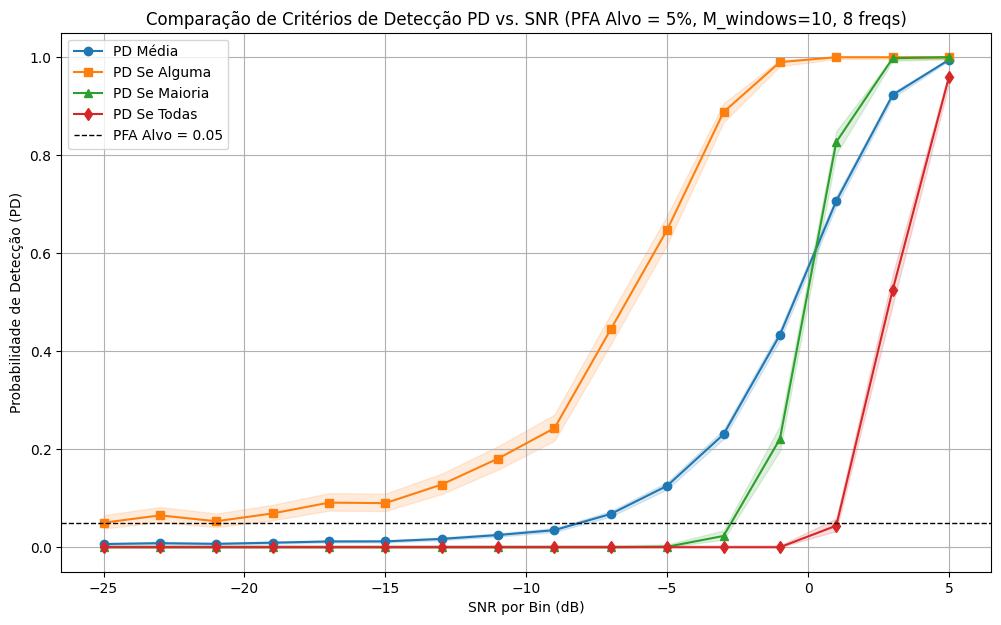

Simulação multifrequência com múltiplos critérios concluída.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, scoreatpercentile
import time

# --- Funções Auxiliares (msc_fft_py e wilson_score_interval_py da resposta anterior) ---
def msc_fft_py(Y_input, M_win):
    if Y_input.shape[1] == 0 or M_win == 0: return np.zeros(Y_input.shape[0])
    current_M_win = min(M_win, Y_input.shape[1])
    if current_M_win == 0: return np.zeros(Y_input.shape[0])
    if current_M_win == 1: return np.ones(Y_input.shape[0])
    Y_to_use = Y_input[:, :current_M_win]
    numerator = np.abs(np.sum(Y_to_use, axis=1))**2
    denominator = current_M_win * np.sum(np.abs(Y_to_use)**2, axis=1)
    msc = np.zeros_like(numerator, dtype=float)
    valid_den = denominator != 0
    msc[valid_den] = numerator[valid_den] / denominator[valid_den]
    msc[np.isnan(msc)] = 0; msc[np.isinf(msc)] = 0
    return msc

def wilson_score_interval_py(k, n, confidence_level=0.95):
    if n == 0: return np.nan, (np.nan, np.nan)
    alpha = 1 - confidence_level; z = norm.ppf(1 - alpha / 2)
    phat = k / n
    term1 = phat + (z**2) / (2 * n)
    term2 = z * np.sqrt((phat * (1 - phat) / n) + (z**2) / (4 * n**2))
    denominator = 1 + (z**2) / n
    pci_l = max(0, (term1 - term2) / denominator)
    pci_u = min(1, (term1 + term2) / denominator)
    return phat, (pci_l, pci_u)

# --- Parâmetros da Simulação ---
FS = 1000
NFFT_msc = 512
M_windows = 10

signal_frequencies = np.array([82, 84, 86, 88, 90, 92, 94, 96])
fp_frequencies = np.array([82, 84, 86, 88, 90, 92, 94, 96])
num_signal_freqs = len(signal_frequencies)
num_fp_freqs = len(fp_frequencies)

target_pfa = 0.05
N_trials_H0 = 10000 # Reduzido para tempo de execução
N_master_trials_H1 = 1000 

snr_db_per_bin_range = np.arange(-25, 5 + 1, 2)

total_samples_msc = NFFT_msc * M_windows
t_msc_segment = np.arange(NFFT_msc) / FS
hanning_win_msc = np.hanning(NFFT_msc)

fp_bin_indices_py = np.zeros(num_fp_freqs, dtype=int)
fp_frequencies_adj = np.zeros(num_fp_freqs)
for i, f_val in enumerate(fp_frequencies):
    bin_idx_ideal = int(round(f_val * NFFT_msc / FS))
    fp_frequencies_adj[i] = bin_idx_ideal * FS / NFFT_msc
    fp_bin_indices_py[i] = bin_idx_ideal
print(f"Frequências de FP ajustadas: {fp_frequencies_adj}")

signal_bin_indices_py = np.zeros(num_signal_freqs, dtype=int)
signal_frequencies_adj = np.zeros(num_signal_freqs)
for i, f_val in enumerate(signal_frequencies):
    bin_idx_ideal = int(round(f_val * NFFT_msc / FS))
    signal_frequencies_adj[i] = bin_idx_ideal * FS / NFFT_msc
    signal_bin_indices_py[i] = bin_idx_ideal
print(f"Frequências de Sinal ajustadas: {signal_frequencies_adj}")

# --- Parte 1: Determinação do Limiar da MSC (H0) ---
print(f'Calculando limiar da MSC para PFA = {target_pfa:.2f} (H0)...')
start_time_h0 = time.time()
max_msc_values_H0_at_fp_freqs = np.zeros(N_trials_H0)
sigma_n_sq_time = 1.0

for i in range(N_trials_H0):
    noise_all_windows_H0 = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
    Y_fft_H0_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
    for k in range(M_windows):
        start_idx = k * NFFT_msc; end_idx = (k + 1) * NFFT_msc
        window_data = noise_all_windows_H0[start_idx:end_idx]
        Y_fft_H0_all_windows[:, k] = np.fft.rfft(window_data * hanning_win_msc)
        
    msc_spectrum_H0 = msc_fft_py(Y_fft_H0_all_windows, M_windows)
    
    valid_indices_h0 = fp_bin_indices_py[(fp_bin_indices_py >= 0) & (fp_bin_indices_py < len(msc_spectrum_H0))]
    if msc_spectrum_H0 is not None and len(valid_indices_h0) == num_fp_freqs :
        msc_at_fp_bins = msc_spectrum_H0[valid_indices_h0]
        max_msc_values_H0_at_fp_freqs[i] = np.max(msc_at_fp_bins)
    else:
        max_msc_values_H0_at_fp_freqs[i] = np.nan
        
    if (i + 1) % (N_trials_H0 // 10) == 0 and N_trials_H0 >=10: print(f'  H0 trial {i+1}/{N_trials_H0}')

max_msc_values_H0_at_fp_freqs = max_msc_values_H0_at_fp_freqs[~np.isnan(max_msc_values_H0_at_fp_freqs)]
if len(max_msc_values_H0_at_fp_freqs) == 0:
    raise ValueError("Não foi possível calcular valores de MSC para H0. Verifique os índices dos bins.")
threshold_msc = scoreatpercentile(max_msc_values_H0_at_fp_freqs, (1 - target_pfa) * 100)
end_time_h0 = time.time()
print(f'Limiar MSC (baseado no max das freqs de FP) determinado: {threshold_msc:.4f} (Tempo H0: {end_time_h0 - start_time_h0:.2f}s)')

# --- Parte 2: Cálculo da PD para diferentes Critérios (H1) ---
pd_crit_list = [] # Lista de dicionários para armazenar resultados
criteria_names = ['PD Média', 'PD Se Alguma', 'PD Se Maioria', 'PD Se Todas']
num_criteria = len(criteria_names)

for name in criteria_names:
    pd_crit_list.append({
        'name': name,
        'values': np.zeros(len(snr_db_per_bin_range)),
        'ic_lower': np.zeros(len(snr_db_per_bin_range)),
        'ic_upper': np.zeros(len(snr_db_per_bin_range))
    })

P_n_bin_expected = (2.0 / NFFT_msc) * sigma_n_sq_time

print('Calculando PD para diferentes SNRs e Critérios (H1)...')
start_time_h1_total = time.time()

for snr_idx, current_snr_db in enumerate(snr_db_per_bin_range):
    start_time_snr_loop = time.time()
    current_snr_linear = 10**(current_snr_db / 10)
    P_s_bin_target = current_snr_linear * P_n_bin_expected
    A_signal = np.sqrt(2 * P_s_bin_target)
    
    detections_count_crit = np.zeros(num_criteria, dtype=int)
    
    for master_trial in range(N_master_trials_H1):
        individual_detections_this_master_trial = np.zeros(num_signal_freqs, dtype=int)
        
        for sig_f_idx in range(num_signal_freqs):
            current_f_signal = signal_frequencies_adj[sig_f_idx]
            current_signal_actual_bin = signal_bin_indices_py[sig_f_idx]
            
            s_t_single_window = A_signal * np.sin(2 * np.pi * current_f_signal * t_msc_segment)
            s_t_all_windows = np.tile(s_t_single_window, M_windows)
            
            n_t_all_windows = np.sqrt(sigma_n_sq_time) * np.random.randn(total_samples_msc)
            x_t_all_windows = s_t_all_windows + n_t_all_windows
            
            Y_fft_H1_all_windows = np.zeros((NFFT_msc // 2 + 1, M_windows), dtype=complex)
            for k_win in range(M_windows):
                start_idx = k_win * NFFT_msc; end_idx = (k_win + 1) * NFFT_msc
                window_data = x_t_all_windows[start_idx:end_idx]
                Y_fft_H1_all_windows[:, k_win] = np.fft.rfft(window_data * hanning_win_msc)
                
            msc_spectrum_H1 = msc_fft_py(Y_fft_H1_all_windows, M_windows)
            
            current_msc_at_signal_bin = np.nan
            if msc_spectrum_H1 is not None and len(msc_spectrum_H1) > current_signal_actual_bin and current_signal_actual_bin >=0 :
                 current_msc_at_signal_bin = msc_spectrum_H1[current_signal_actual_bin]

            if not np.isnan(current_msc_at_signal_bin) and current_msc_at_signal_bin > threshold_msc:
                individual_detections_this_master_trial[sig_f_idx] = 1
        
        num_detected_in_master_trial = np.sum(individual_detections_this_master_trial)
        
        detections_count_crit[0] += num_detected_in_master_trial # Para PD Média
        if num_detected_in_master_trial > 0: detections_count_crit[1] += 1
        if num_detected_in_master_trial > (num_signal_freqs / 2): detections_count_crit[2] += 1
        if num_detected_in_master_trial == num_signal_freqs: detections_count_crit[3] += 1
            
    total_individual_detection_opportunities = N_master_trials_H1 * num_signal_freqs
    pd_val1, (ic_low1, ic_upp1) = wilson_score_interval_py(detections_count_crit[0], total_individual_detection_opportunities)
    pd_crit_list[0]['values'][snr_idx] = pd_val1
    pd_crit_list[0]['ic_lower'][snr_idx] = ic_low1; pd_crit_list[0]['ic_upper'][snr_idx] = ic_upp1

    for c_idx in range(1, num_criteria): # Critérios 2, 3, 4
        pd_val, (ic_low, ic_upp) = wilson_score_interval_py(detections_count_crit[c_idx], N_master_trials_H1)
        pd_crit_list[c_idx]['values'][snr_idx] = pd_val
        pd_crit_list[c_idx]['ic_lower'][snr_idx] = ic_low
        pd_crit_list[c_idx]['ic_upper'][snr_idx] = ic_upp
    
    print(f'  SNR={current_snr_db:.1f}dB: PD_M={pd_crit_list[0]["values"][snr_idx]:.3f}, '
          f'PD_Any={pd_crit_list[1]["values"][snr_idx]:.3f}, '
          f'PD_Maj={pd_crit_list[2]["values"][snr_idx]:.3f}, '
          f'PD_All={pd_crit_list[3]["values"][snr_idx]:.3f}')
    
end_time_h1_total = time.time()
print(f'Tempo total H1: {end_time_h1_total - start_time_h1_total:.2f}s')

# --- Parte 3: Plotagem ---
plt.figure(figsize=(12, 7)) # Aumentado para melhor visualização
plot_styles = ['-o', '-s', '-^', '-d']
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

for c_idx in range(num_criteria):
    plt.plot(snr_db_per_bin_range, pd_crit_list[c_idx]['values'], plot_styles[c_idx],
             color=colors[c_idx % len(colors)], linewidth=1.5, label=pd_crit_list[c_idx]['name'])
    plt.fill_between(snr_db_per_bin_range, pd_crit_list[c_idx]['ic_lower'], pd_crit_list[c_idx]['ic_upper'],
                     color=colors[c_idx % len(colors)], alpha=0.15)

plt.axhline(target_pfa, color='k', linestyle='--', linewidth=1,
            label=f'PFA Alvo = {target_pfa:.2f}')
            
plt.xlabel('SNR por Bin (dB)')
plt.ylabel('Probabilidade de Detecção (PD)')
plt.title(f'Comparação de Critérios de Detecção PD vs. SNR (PFA Alvo = {target_pfa*100:.0f}%, M_windows={M_windows}, {num_signal_freqs} freqs)')
plt.legend(loc='best') # Alterado para 'best' para melhor posicionamento
plt.grid(True)
plt.ylim([-0.05, 1.05])
plt.show()

print('Simulação multifrequência com múltiplos critérios concluída.')